In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from scipy.stats import ttest_1samp, ttest_ind
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

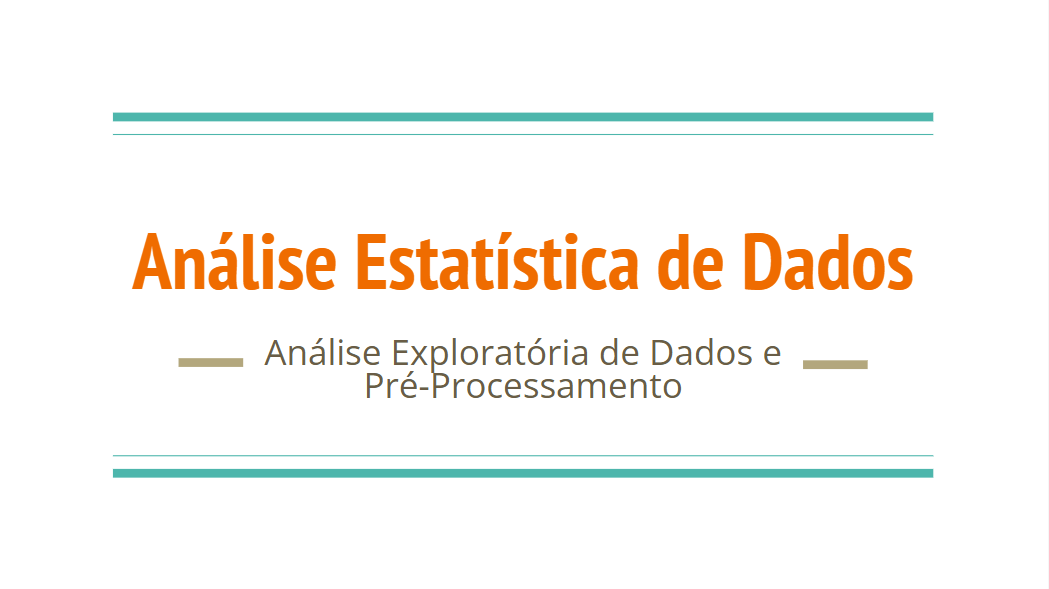

## Introdução

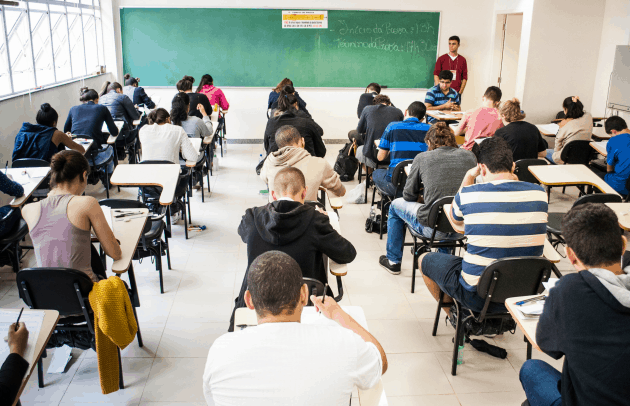

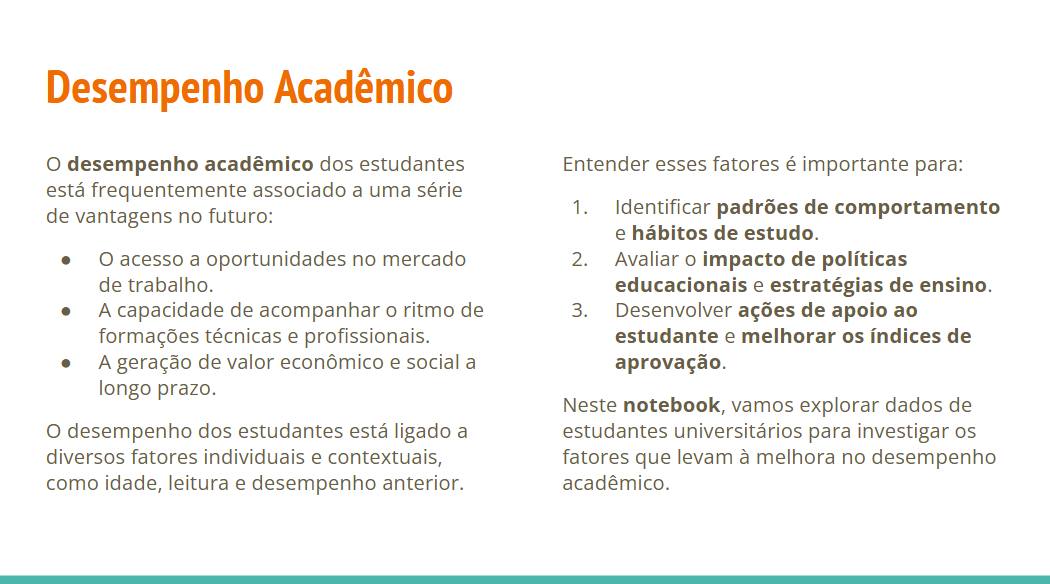

## Importação de Dados

O dataset reúne informações sobre **estudantes universitário**s e diversos fatores que podem influenciar seu desempenho acadêmico.

Cada linha representa um aluno e inclui variáveis demográficas, comportamentais e acadêmicas, como idade, tipo de bolsa, frequência às aulas, horas de estudo por semana, entre outras.

Neste notebook, vamos focar na **análise dos fatores associados ao desempenho final dos estudantes**, explorando como diferentes características estão relacionadas às notas obtidas ao final do curso.

A primeira coisa que precisamos fazer é importar o conjunto de dados.

In [2]:
df = pd. read_csv('dados_estudantes.csv')

print(f'Dimensionalidade do dataset: {df.shape}')

df.head()

Dimensionalidade do dataset: (145, 9)


,index,Idade,Gênero,Tipo de bolsa,Horas de estudo por semana,Frequência às aulas,Frequência de leitura científica,CRA semestre anterior,Nota final
0,0,23,Masculino,50%,8.4,Sempre,Às vezes,0.73,DD
1,1,24,Masculino,50%,2.0,Sempre,Às vezes,2.37,DD
2,2,22,Masculino,50%,2.7,Sempre,Nunca,2.48,DD
3,3,21,Feminino,50%,6.7,Sempre,Nunca,2.92,DD
4,4,22,Masculino,50%,4.7,Sempre,Nunca,2.39,DD


### Descrição das variáveis

* `index`: índice dos alunos, de 0 a 144.

* `Idade`: idade do estudante, entre 18 e 35 anos.

* `Gênero`: sexo do estudante (Feminino ou Masculino).

* `Tipo de bolsa`: nível de bolsa recebida (Nenhuma, 25%, 50%, 75% ou Integral).

* `Horas de estudo por semana`: número estimado de horas dedicadas ao estudo semanal.

* `Frequência às aulas`: frequência de presença nas aulas (Sempre, Às vezes ou Nunca).

* `Frequência de leitura científica`: frequência de leitura de livros e artigos científicos (Nunca, Às vezes ou Frequentemente).

* `CRA semestre anterior`: coeficiente de rendimento acadêmico do semestre anterior (entre 0.0 e 4.0).

* `Nota final`: desempenho final na disciplina (Reprovado, DD, DC, CC, CB, BB, BA, AA).

## Análise Univariada

A primeira coisa que podemos fazer é explorar o **comportamento** de **variáveis individuais**. Podemos fazer isso de duas formas, usando gráficos e estatísticas.

Para isso, precisamos antes saber o tipo de cada variável.

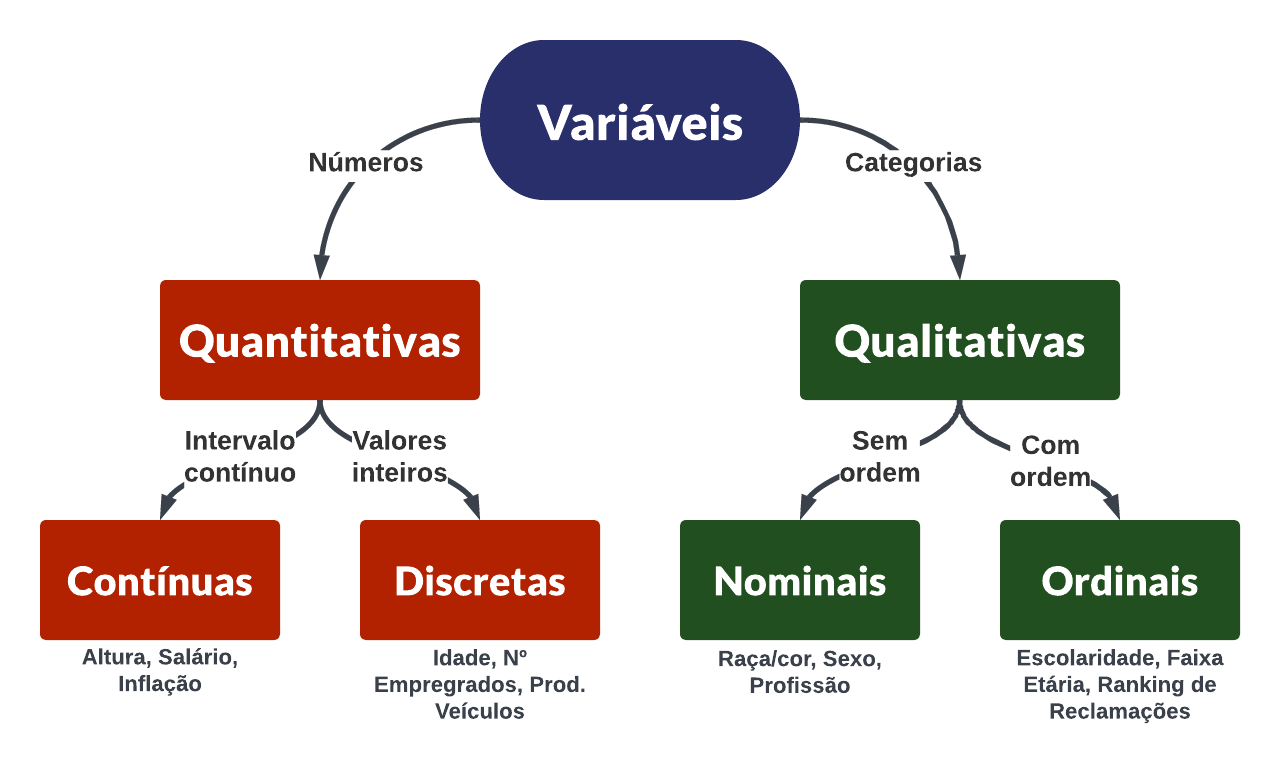

Para cada variável do nosso dataset, diga de que tipo elas são.

In [ ]:
# Resposta
'''
Idade: Quantitativa Contínua
Gênero: Qualitativa Binária
Tipo de bolsa: Qualitativa Ordinal
Horas de estudo por semana: Quantitativa Contínua
Frequência às aulas: Qualitativa Ordinal
Frequência de leitura científica: Qualitativa Ordinal
CRA semestre anterior: Quantitativa Contínua
Nota final: Qualitativa Ordinal
'''

'\nIdade: Quantitativa Contínua\nGênero: Qualitativa Binária\nTipo de bolsa: Qualitativa Ordinal\nHoras de estudo por semana: Quantitativa Contínua\nFrequência às aulas: Qualitativa Ordinal\nFrequência de leitura científica: Qualitativa Ordinal\nCRA semestre anterior: Quantitativa Contínua\nNota final: Qualitativa Ordinal\n'

### Variáveis Categóricas

Variáveis categóricas são aquelas que expressam uma classe. Vamos analisar uma delas, a variável `tipo de bolsa`. Podemos perguntas quais são os valores mais frequentes dessa variável, tanto em termos absolutos quanto relativos.

A primeira maneira de fazer isso é por meio de uma **tabela de frequência**.

In [3]:
# Tabela de frequência absoluta
frequencia_abs = df['Tipo de bolsa'].value_counts().sort_index()

# Tabela de frequência relativa
frequencia_rel = df['Tipo de bolsa'].value_counts(normalize=True).sort_index() * 100

# Junta em uma tabela única
tabela_freq = pd.DataFrame({
    'Frequência Absoluta': frequencia_abs,
    'Frequência Relativa (%)': frequencia_rel.round(2)
})

print("Tabela de Frequência:")
print(tabela_freq)

Tabela de Frequência:
               Frequência Absoluta  Frequência Relativa (%)
Tipo de bolsa                                              
25%                              3                     2.07
50%                             76                    52.41
75%                             42                    28.97
Integral                        23                    15.86
Nenhuma                          1                     0.69


Outra forma é por meio de representações visuais; isto é, **gráficos**. Eles permitem uma compreensão mais rápida e intuitiva da distribuição dos dados.

Dois tipos comuns de gráficos para variáveis qualitativas são:

* **Gráfico de barras:** mostra a frequência absoluta de cada categoria. É ideal para comparar valores e identificar facilmente qual categoria ocorre com mais ou menos frequência.

* **Gráfico de pizza:** representa a frequência relativa (proporção) de cada categoria em relação ao total. É útil para visualizar a participação percentual de cada grupo no conjunto.

Ambos ajudam a destacar padrões, facilitar comparações e apoiar análises mais interpretativas dos dados.

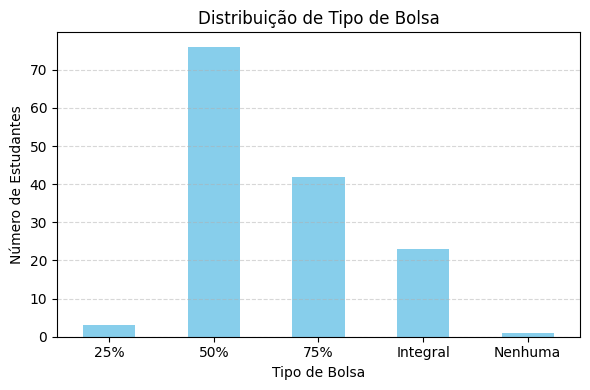

In [4]:
# Gráfico de barras
plt.figure(figsize=(6,4))
df['Tipo de bolsa'].value_counts().sort_index().plot(kind='bar', color='skyblue')
plt.title('Distribuição de Tipo de Bolsa')
plt.xlabel('Tipo de Bolsa')
plt.ylabel('Número de Estudantes')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

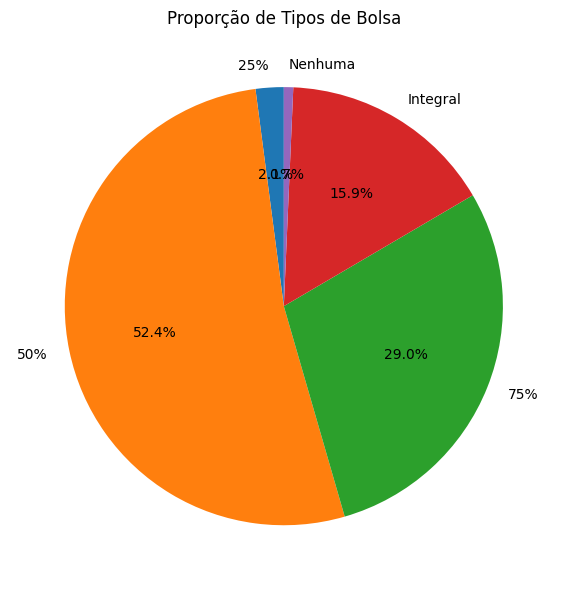

In [5]:
# Gráfico de pizza
plt.figure(figsize=(6,6))
df['Tipo de bolsa'].value_counts().sort_index().plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title('Proporção de Tipos de Bolsa')
plt.ylabel('')  # Remove label do eixo y
plt.tight_layout()
plt.show()

### Variáveis Quantitativas

Para variáveis quantitativas, especialmente variáveis contínuas, que podem assumir qualquer valor, precisamos utilizar outra forma de representação. A maneira mais simples é agrupar os valores em **intervalos**. As contagens para cada intervalo são representadas por meio de um **histograma**.

Vamos analisar as notas do semestre anterior, utilizando a variável quantatitiva `CRA semestre anterior`.

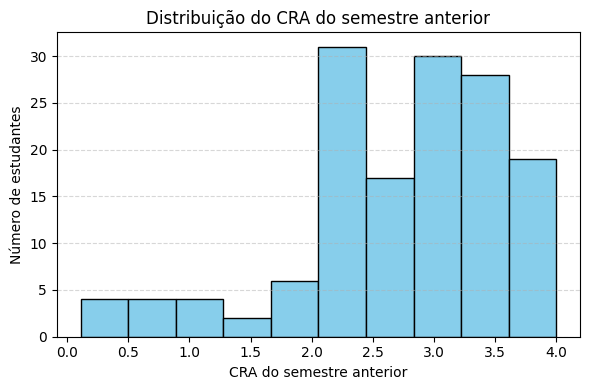

In [6]:
plt.figure(figsize=(6, 4))
plt.hist(df['CRA semestre anterior'], bins=10, color='skyblue', edgecolor='black')
plt.title('Distribuição do CRA do semestre anterior')
plt.xlabel('CRA do semestre anterior')
plt.ylabel('Número de estudantes')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**Conclusão:** A maioria dos alunos obteve notas entre 2.1 e 4.0.

Podemos também procurar pelas estatísticas descritivas, em particular medidas de **posição** e **dispersão**. Elas apresentam **valores representativos** do nosso conjunto de dados. As estatísticas descritivas também são uma ferramenta útil para encontrar potenciais problemas nos dados.

In [7]:
df['Horas de estudo por semana'].describe()

,Horas de estudo por semana
count,145.000000
mean,4.380690
std,5.436033
min,0.000000
25%,0.700000
50%,2.600000
75%,6.300000
max,28.900000


### Box Plot

Com as estatísticas descritivas, podemos construir um **box plot**.

O **box plot** utiliza os principais elementos da distribuição de uma variável quantitativa — como a mediana, os quartis e os valores extremos — para resumir visualmente o comportamento dos dados.

O box plot mostra:

* A mediana (linha central da caixa).

* O 1º e 3º quartis (bordas da caixa, que delimitam 50% dos dados centrais).

* Os limites inferior e superior (chamados "bigodes"), que indicam a faixa de dados não considerados outliers.

* Outliers como pontos individuais, quando existem.

O boxplot permite identificar rapidamente características importantes como tendência central, dispersão, assimetria e presença de outliers.

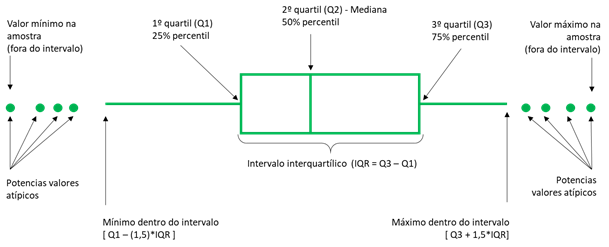

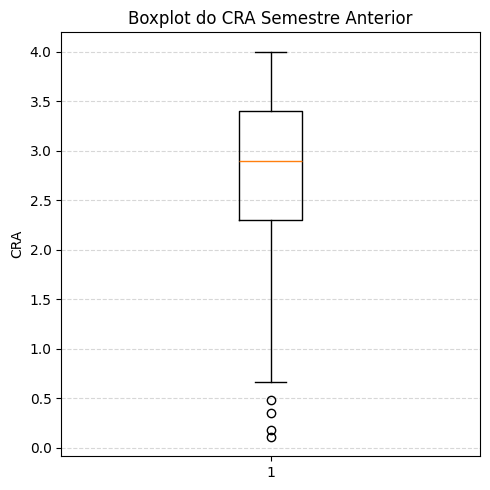

In [8]:
plt.figure(figsize=(5, 5))
plt.boxplot(df['CRA semestre anterior'], vert=True)
plt.title('Boxplot do CRA Semestre Anterior')
plt.ylabel('CRA')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Como se pode ver, há quatro outliers abaixo do limite inferior. Veremos como lidar com esses dados mais à frente.

## Análise Bivariada

Tão interessante quanto entender o comportamento individual das variáveis, é entender como elas se **relacionam conjuntamente**.

### Variáveis Quantitativas

Visualmente, podemos analisar a relação entre variáveis quantitativas por meio de um **gráfico de dispersão**.

Um **gráfico de dispersão** (ou *scatter plot*) é uma representação gráfica utilizada para visualizar a relação entre duas variáveis quantitativas. Cada ponto no gráfico representa uma observação, onde:

* A coordenada x indica o valor de uma variável independente (ou preditora);

* A coordenada y indica o valor de uma variável dependente (ou resposta).

Esse tipo de gráfico é especialmente útil para:

* Identificar correlações (positiva, negativa ou nula);

* Detectar padrões ou tendências;

* Observar dispersão, agrupamentos ou outliers;

* Avaliar a linearidade ou não de uma relação.

**IMPORTANTE:** A análise de gráficos não configura um **teste estatístico** sistemático.

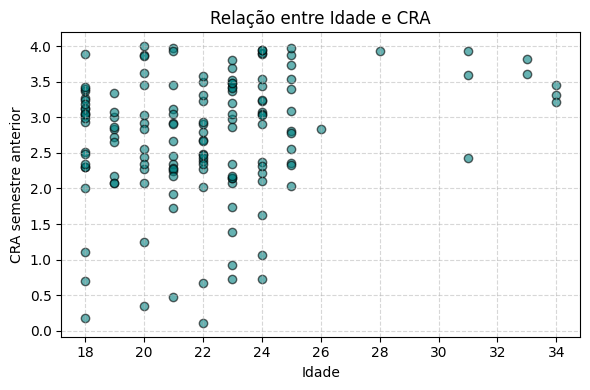

In [ ]:
plt.figure(figsize=(6, 4))
plt.scatter(df['Idade'], df['CRA semestre anterior'], alpha=0.6, color='teal', edgecolor='black')
plt.title('Relação entre Idade e CRA')
plt.xlabel('Idade')
plt.ylabel('CRA semestre anterior')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**Pergunta:** Qual parece ser a relação entre as duas variáveis?

Para entender a relação entre variáveis de maneira sistemática, podemos calcular a **correlação** entre elas.

A **correlação** é uma medida estatística que indica a força e a direção da relação linear entre duas variáveis numéricas. Seu valor varia de -1 (correlação negativa perfeita) a +1 (correlação positiva perfeita), sendo 0 a ausência de correlação linear.

Vamos calcular a correlação entre todas as variáveis quantitativas do nosso conjunto de dados e exibir os resultados por meio de um **mapa de calor**. Um mapa de calor (*heatmap*) é uma representação visual de dados em que os valores são mostrados por meio de cores.


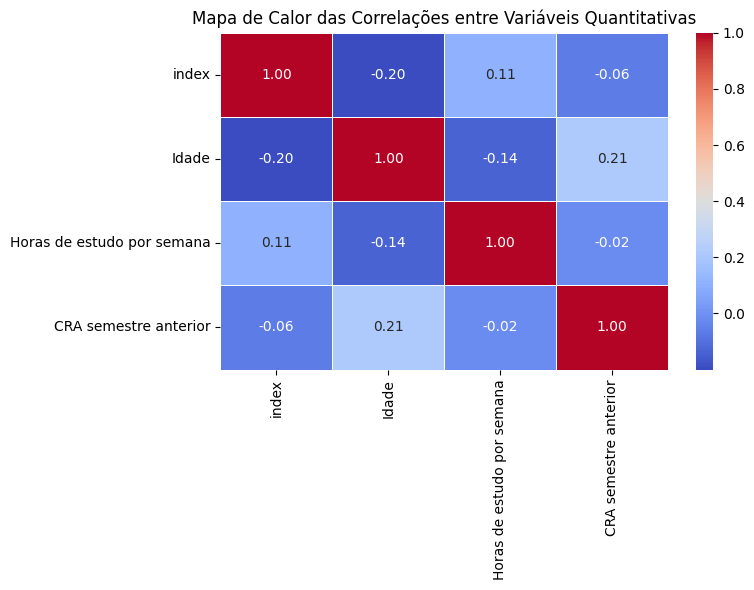

In [9]:
# Seleciona apenas variáveis numéricas
df_numericas = df.select_dtypes(include=['float64', 'int64'])

# Calcula a matriz de correlação
matriz_corr = df_numericas.corr()

# Gera o heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Mapa de Calor das Correlações entre Variáveis Quantitativas')
plt.tight_layout()
plt.show()

### Variáveis Qualitativas

Para variáveis qualitativas, podemos calcular uma **tabela de frequência conjunta**.


In [10]:
tabela_conjunta = pd.crosstab(df['Gênero'], df['Tipo de bolsa'], margins=True)

print(tabela_conjunta)

Tipo de bolsa  25%  50%  75%  Integral  Nenhuma  All
Gênero                                              
Feminino         0   26   19        13        0   58
Masculino        3   50   23        10        1   87
All              3   76   42        23        1  145


**Pergunta:** Parece haver alguma associação entre gênero e tipo de bolsa?

Para visualizar a possível associação entre variáveis qualitativas, podemos utilizar um **gráfico de barras**.

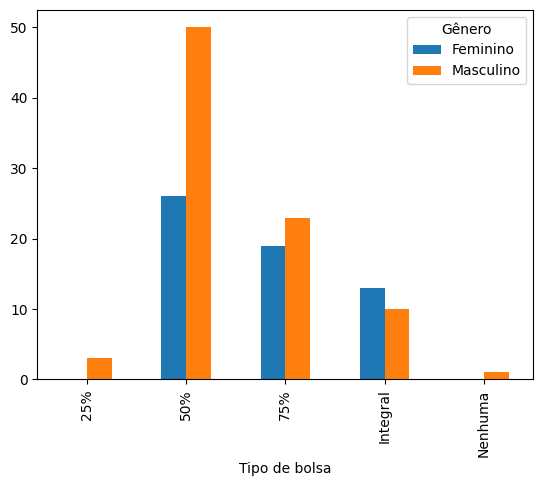

In [11]:
# Gráfico de barras agrupadas
pd.crosstab(df['Tipo de bolsa'], df['Gênero']).plot(kind='bar')
plt.show()

Esse gráfico mostra os valores absolutos. Isso é interessante para entender a dispersão dos dados, mas dificulta a comparação entre as classes. Podemos então normalizar os dados para cada classe. Temos apenas que tomar cuidado que, para conjuntos de dados pequenos, as classes podem não ser representativas (p. ex, há apenas uma pessoa sem bolsa).

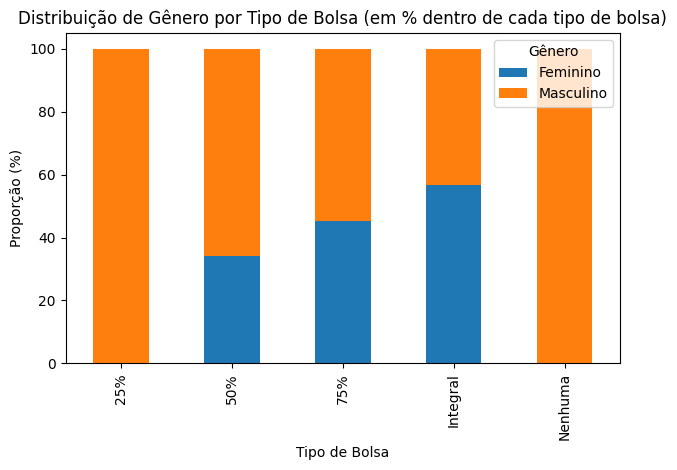

In [12]:
# Normaliza por coluna (por Tipo de Bolsa)
tabela_norm_por_bolsa = pd.crosstab(df['Gênero'], df['Tipo de bolsa'], normalize='columns')

# Multiplica por 100 para exibir como porcentagem
tabela_percentual = tabela_norm_por_bolsa * 100

# Transpõe para plotar com o eixo X sendo o tipo de bolsa
tabela_percentual.T.plot(kind='bar', stacked=True)

plt.title('Distribuição de Gênero por Tipo de Bolsa (em % dentro de cada tipo de bolsa)')
plt.ylabel('Proporção (%)')
plt.xlabel('Tipo de Bolsa')
plt.legend(title='Gênero')
plt.tight_layout()
plt.show()

Como vimos na aula de estatística descritiva, existe um teste de associação entre variáveis qualitativas, o **teste de qui-quadrado**.

O teste do qui-quadrado de independência verifica se há associação entre duas variáveis categóricas, comparando as frequências observadas com as esperadas sob a hipótese de independência. Se o valor-p for pequeno, indica que as variáveis estão associadas.

A fórmula para calcular a estatística é a seguinte:

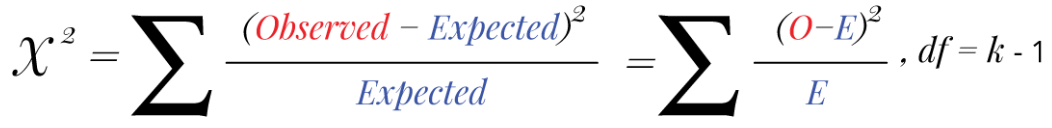

Testamos as seguintes hipóteses:
* **Hipótese nula (H₀):** As variáveis são independentes (não há associação entre Gênero e Tipo de Bolsa).

* **Hipótese alternativa (H₁):** As variáveis são associadas (a distribuição de um depende do outro).


In [13]:
# Remover a linha e coluna de totais (margins=True gera uma linha e coluna chamada "All")
tabela_sem_margens = tabela_conjunta.drop(index='All', columns='All')

# Aplicar o teste do qui-quadrado
chi2, p, dof, expected = chi2_contingency(tabela_sem_margens)

print(f'Estatística do qui-quadrado: {chi2}')
print(f'Valor-p: {p}')

Estatística do qui-quadrado: 6.824170934582834
Valor-p: 0.14547689611961712


**Interpretação:**
* O **p-valor** (0.145) é maior que 0.05, então **não rejeitamos** a hipótese nula.
* Isso significa que **não há evidência estatisticamente significativa** de associação entre Gênero e Tipo de bolsa com base nos seus dados.
* Em outras palavras, a distribuição dos tipos de bolsa não varia significativamente entre os diferentes gêneros.

**Observação:**
* Alguns valores esperados são menores que 5 (por exemplo, 0.4 e 0.6). Isso viola uma das premissas do teste de qui-quadrado, que recomenda valores esperados ≥ 5 para a maioria das células, enfraquecendo a confiabilidade do resultado.

### Variável Quantativa e Qualitativa

Para analisar a associação entre variáveis quantitativas e qualitativas, podemos usar um **box plot quebrado por classes**. Esse tipo de gráfico permite visualizar a distribuição da variável numérica dentro de cada categoria da variável qualitativa.

Com ele, conseguimos observar:

* Diferenças nas medianas entre os grupos.

* A dispersão dos valores (amplitude interquartil).

* A presença de outliers.

* Possíveis tendências ou padrões entre as categorias.

É uma ferramenta útil para investigar, por exemplo, se o desempenho acadêmico varia entre os tipos de bolsa ou se as horas de estudo diferem entre os gêneros.

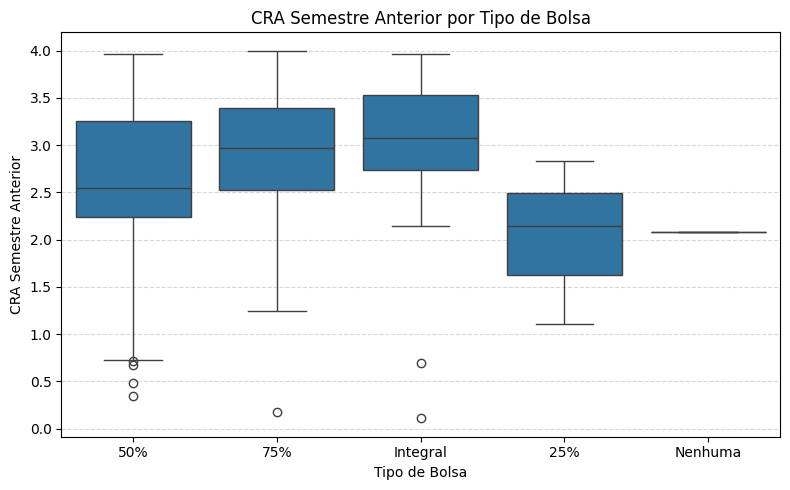

In [14]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Tipo de bolsa', y='CRA semestre anterior')
plt.title('CRA Semestre Anterior por Tipo de Bolsa')
plt.xlabel('Tipo de Bolsa')
plt.ylabel('CRA Semestre Anterior')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**Pergunta:** Parece haver alguma relação entre as duas variáveis em questão?

Podemos também tentar analisar estatisticamente a associação entre as variáveis `Gênero` e `CRA do Semestre Anterior`. Vamos utilizar o **teste t de Student** que vimos na aula passada para verificar se há uma diferença significativa entre as médias dos grupos.

**Observações:**
* Esse teste só se aplica se a variável tiver somente duas categorias. Caso tenha mais, usamos ANOVA.
* Não usamos o teste t padrão, mas o teste t de Welch (`equal_var=False`). Essa é uma versão mais segura do teste t que não assume variâncias iguais entre os grupos. É recomendado quando não temos certeza se as variâncias são parecidas.


In [15]:
categorias = df['Tipo de bolsa'].unique()

grupo1 = df[df['Tipo de bolsa'] == categorias[0]]['CRA semestre anterior']
grupo2 = df[df['Tipo de bolsa'] == categorias[1]]['CRA semestre anterior']
t_stat, p_value = ttest_ind(grupo1, grupo2, equal_var=False)  # Welch's t-test
print(f'Teste t de Student (variâncias não assumidas iguais):')
print(f'Estatística t = {t_stat:.4f}, p-valor = {p_value:.4f}')

Teste t de Student (variâncias não assumidas iguais):
Estatística t = -1.8621, p-valor = 0.0657


**Interpretação:**
* Como o **p-valor** (0.0657) é maior que 0.05, não rejeitamos a hipótese nula ao nível de 5% de significância.
* Ou seja, **não há evidência estatisticamente significativa** de que as médias de CRA sejam diferentes entre os dois tipos de bolsa.
* Contudo, como o valor-p está relativamente perto de 0.05, pode indicar uma tendência à diferença, e poderia ser investigado com mais dados ou usando um nível de significância de 10%.

### Teste de Hipótese

O **teste de hipótese**, que estudamos na aula passada, oferece procedimentos sistemáticos para testar certos pressupostos sobre os parâmetros da população.

Podemos ver se um parâmetro populacional, como a média, é igual ou diferente de um valor específico, ou se duas populações possuem médias distintas. Em ambos os casos, formulamos hipóteses nula e alternativa, e usamos o valor-p (p-valor) para tomar a decisão estatística.

**Caso 1:** testar se os estudantes estudam mais de 6 horas por semana, em média. Nesse caso, comparamos a média da amostra com o valor fixo 6, utilizando um teste t para uma amostra.

* **Hipótese nula (H₀):** A média de horas de estudo por semana é maior ou igual a 6 horas.

* **Hipótese alternativa (H₁):** A média de horas de estudo por semana é menor que 6 horas.


In [16]:
# Dados
horas = df['Horas de estudo por semana'].dropna()

# Teste t com média de referência igual a 6
t_stat, p_val = ttest_1samp(horas, popmean=6)

# Ajuste do p-valor para teste unilateral à esquerda (H₁: média < 5)
p_val_unilateral = p_val / 2 if horas.mean() < 6 else 1 - (p_val / 2)

# Impressão dos resultados
print("H₀: média ≥ 6")
print("H₁: média < 6")
print(f"t = {t_stat:.3f}, p = {p_val_unilateral:.4f}")

H₀: média ≥ 6
H₁: média < 6
t = -3.587, p = 0.0002


**Conclusão:**

* Como p < 0.05, rejeitamos H₀.

* Há evidência estatística suficiente para afirmar que os estudantes estudam, em média, menos de 6 horas por semana.




**Caso 2:** investigar se mulheres têm nota (CRA) maior que homens. Aqui, comparamos duas médias amostrais, utilizando um teste t para duas amostras independentes.

In [17]:
# Supondo que a coluna 'Gênero' tem valores 'Feminino' e 'Masculino'
mulheres = df[df['Gênero'] == 'Feminino']['CRA semestre anterior'].dropna()
homens = df[df['Gênero'] == 'Masculino']['CRA semestre anterior'].dropna()

# Teste t (amostras independentes, var equal ou não)
t_stat, p_val = ttest_ind(mulheres, homens, equal_var=False)

# Teste unilateral (mulheres > homens)
p_val_unilateral = p_val / 2 if mulheres.mean() > homens.mean() else 1 - (p_val / 2)

print(f"H₀: média CRA mulheres = média CRA homens")
print(f"t = {t_stat:.3f}, p = {p_val_unilateral:.4f}")

H₀: média CRA mulheres = média CRA homens
t = -2.865, p = 0.9975


**Conclusão:**

* Como p > 0.05, não rejeitamos H₀.

* Não há evidência estatística de que as mulheres tenham notas maiores do que os homens no CRA do semestre anterior.

## Pré-Processamento

Nem sempre os dados chegam num formato adequado para os nossos objetivos. Isso vale tanto para a **análise exploratória de dados** quanto para o treinamento de modelos de **aprendizado de máquina**. Algumas dessas etapas são comuns a ambas as atividades, outras são específicas do aprendizado de máquina.

Vamos ver todas as etapas que constituem o **pré-processamento** de dados.

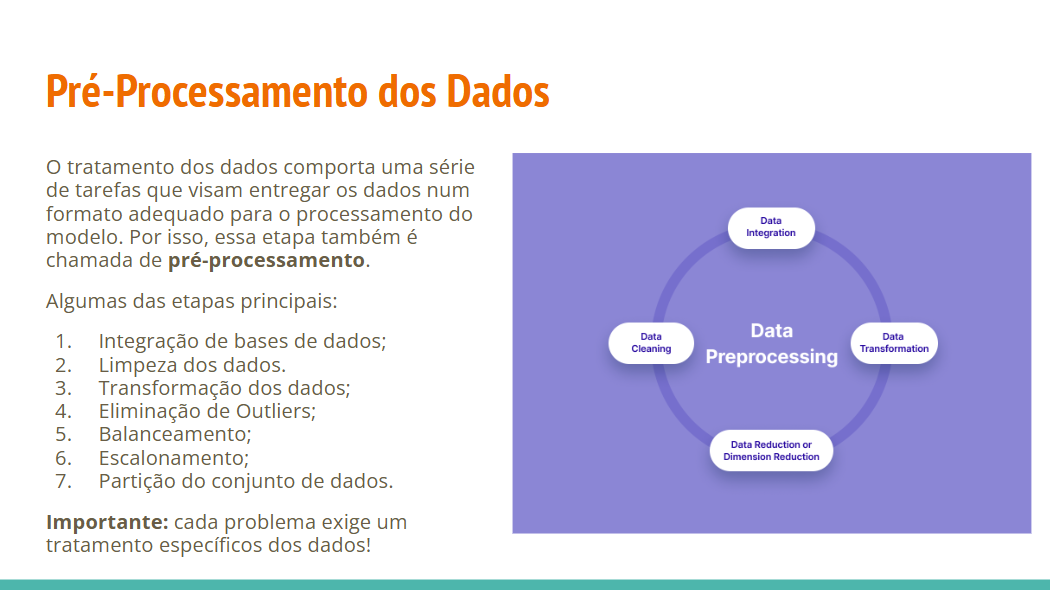

#### 1. Aquisição e Integração de Dados

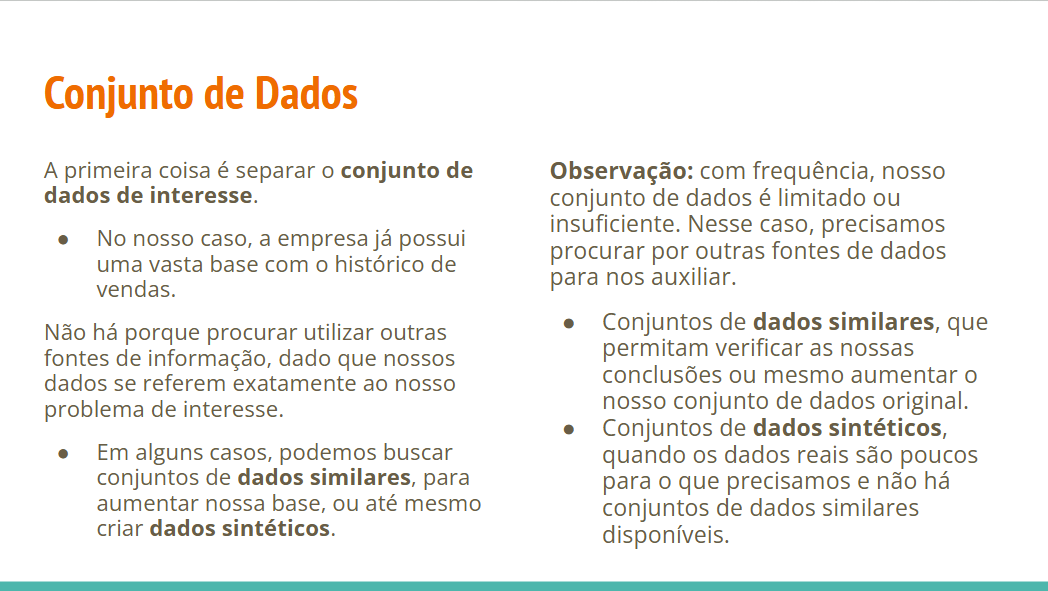

Nosso dataset já contém todas as informações de que precisamos. Não foi preciso procurar novos dados ou integrar diferentes bases.

#### 2. Limpeza dos Dados

Com frequência, os dados que possuímos apresentam uma série de problemas: formato inadequado, valores faltantes, erros de digitação, entre outros problemas. Antes de pensar em treinar um modelo, é necessário garantir que os dados se encontram num formato adequado. Podemos também aproveitar para ajustar nomes de colunas para facilitar as chamadas.


Um exemplo comum de problema são **dados faltantes**. Dados faltantes podem ser um problema sério para vários tipos de modelos, impedindo que possam rodar. Vamos checar se há valores faltantes no nosso dataset e se houver, vamos removê-los.



In [18]:
# Verificar valores faltantes
print("Valores faltantes antes da remoção:")

print(df.isnull().sum())

Valores faltantes antes da remoção:
index                               0
Idade                               0
Gênero                              0
Tipo de bolsa                       0
Horas de estudo por semana          0
Frequência às aulas                 0
Frequência de leitura científica    0
CRA semestre anterior               0
Nota final                          0
dtype: int64


Não há nenhum dando faltante no nosso conjunto de dados, então não precisamos fazer nenhuma modificação nesse sentido.

Há uma série de outras modificações que podem ser feitas:
* Tratar valores duplicados.
* Remover colunas desnecessárias.
* Alterar o nome das colunas para facilitar a chamada.
* Criação de novas variáveis (*feature engeneering*).


Para o nosso caso, vamos proceder à remoção da coluna `index`. Ela contém um número arbitrário para cada aluno, não sendo uma variável informativa.

In [19]:
df.drop('index', axis=1, inplace=True)

df.head()

,Idade,Gênero,Tipo de bolsa,Horas de estudo por semana,Frequência às aulas,Frequência de leitura científica,CRA semestre anterior,Nota final
0,23,Masculino,50%,8.4,Sempre,Às vezes,0.73,DD
1,24,Masculino,50%,2.0,Sempre,Às vezes,2.37,DD
2,22,Masculino,50%,2.7,Sempre,Nunca,2.48,DD
3,21,Feminino,50%,6.7,Sempre,Nunca,2.92,DD
4,22,Masculino,50%,4.7,Sempre,Nunca,2.39,DD


#### 3. Tipos de variáveis

Boa parte dos modelos não aceita **variáveis categóricas**. Portanto, para utilizarmos essas informações, precisamos transformá-las em números, fazendo uma **codificação**.

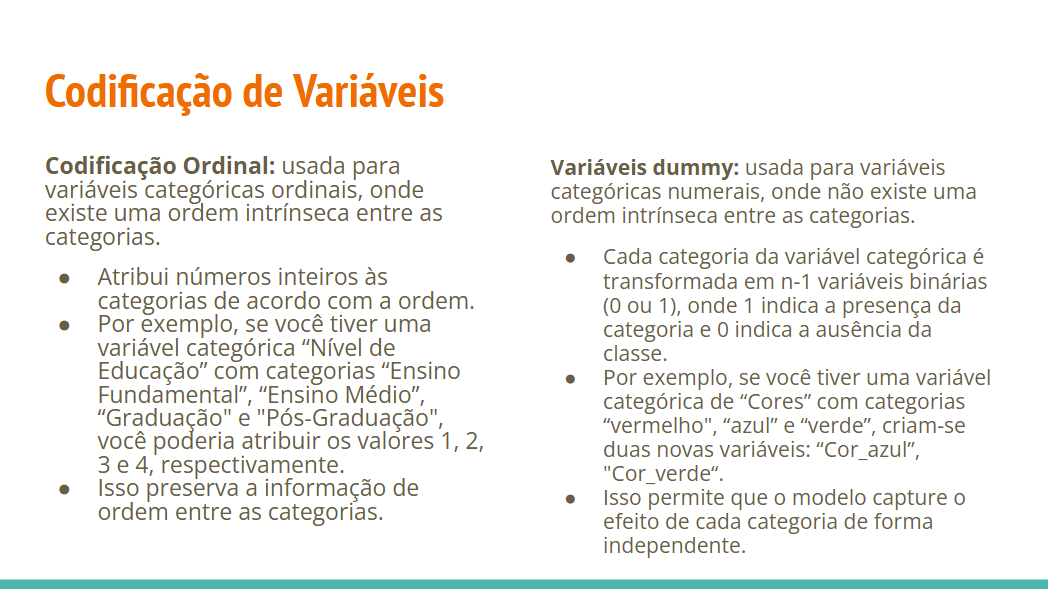

Ainda que não seja uma preocupação direta para nossa análise estatística, vamos fazer uma **codificação one-hot** para ilustrar.

In [20]:
df = pd.get_dummies(df, drop_first=True)

print(df.shape)

df.head()

(145, 18)


,Idade,Horas de estudo por semana,CRA semestre anterior,Gênero_Masculino,Tipo de bolsa_50%,Tipo de bolsa_75%,Tipo de bolsa_Integral,Tipo de bolsa_Nenhuma,Frequência às aulas_Às vezes,Frequência de leitura científica_Nunca,Frequência de leitura científica_Às vezes,Nota final_BA,Nota final_BB,Nota final_CB,Nota final_CC,Nota final_DC,Nota final_DD,Nota final_Reprovado
0,23,8.4,0.73,True,True,False,False,False,False,False,True,False,False,False,False,False,True,False
1,24,2.0,2.37,True,True,False,False,False,False,False,True,False,False,False,False,False,True,False
2,22,2.7,2.48,True,True,False,False,False,False,True,False,False,False,False,False,False,True,False
3,21,6.7,2.92,False,True,False,False,False,False,True,False,False,False,False,False,False,True,False
4,22,4.7,2.39,True,True,False,False,False,False,True,False,False,False,False,False,False,True,False


O parâmetro `drop_first=True` em `get_dummies` elimina colunas redundantes ao remover a primeira categoria de cada variável. Isso é fundamental para evitar multicolinearidade em modelos como regressão linear, onde colunas dummy completamente correlacionadas podem prejudicar o modelo.

#### 4. Outliers

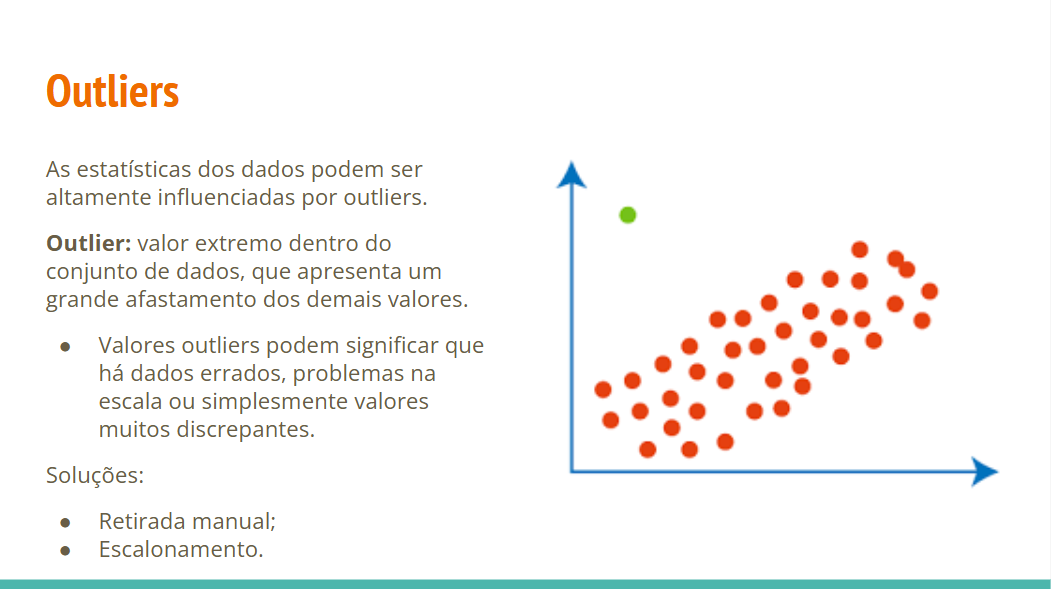

Vejamos o boxplot da variável

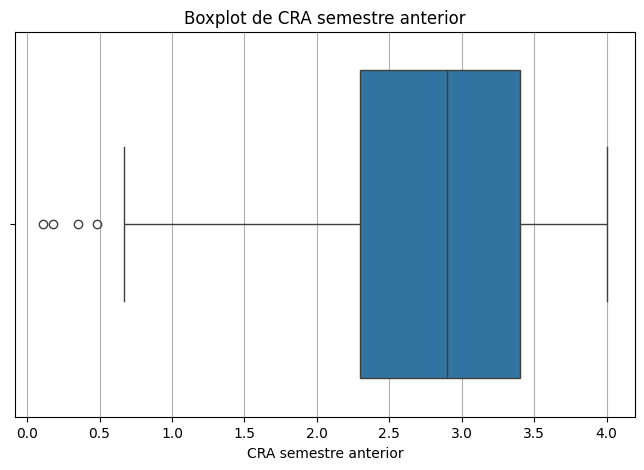

In [21]:
# Criando um boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['CRA semestre anterior'])
plt.title(f'Boxplot de CRA semestre anterior')
plt.xlabel('CRA semestre anterior')
plt.grid(axis='x')
plt.show()

A coluna `CRA semestre anterior` tem quatro valor que se distanciam dos demais. Isso pode ser causado por um erro na leitura dos dados, erro de digitação, ou simplesmente por serem observações diferente das demais.

Esses dados extremos podem ter um grande impacto nas estatística descritivas e também nas estimativas de modelos de aprendizado de máquina. Por esse motivo, é comum eliminá-los da análise.

Uma opção é usar o **Intervalo Interquartil** ou **desvio padrão**.

In [22]:
# Método do Intervalo Interquartil
Q1 = df['CRA semestre anterior'].quantile(0.25)
Q3 = df['CRA semestre anterior'].quantile(0.75)
IQR = Q3 - Q1

filtro = (df['CRA semestre anterior'] >= Q1 - 1.5 * IQR) & (df['CRA semestre anterior'] <= Q3 + 1.5 * IQR)

df_sem_outliers = df[filtro]

In [ ]:
# Método do desvio padrão
#media = df['coluna'].mean()
#desvio = df['coluna'].std()

#filtro = (df['coluna'] >= media - 3 * desvio) & (df['coluna'] <= media + 3 * desvio)
#df_sem_outliers = df[filtro]

Numa análise mais cuidadosa, seria possível decidir a pertinência ou não de um dado de **forma manual**.

#### 5. Balanceamento de Dados

Em tarefas de **classificação**, é preciso garantir que as classes sejam igualmente representadas (ou algo próximo disso). De outra forma, o modelo pode se preocupar demais com a classe majoritária e deixar de lado a classe minoritária.

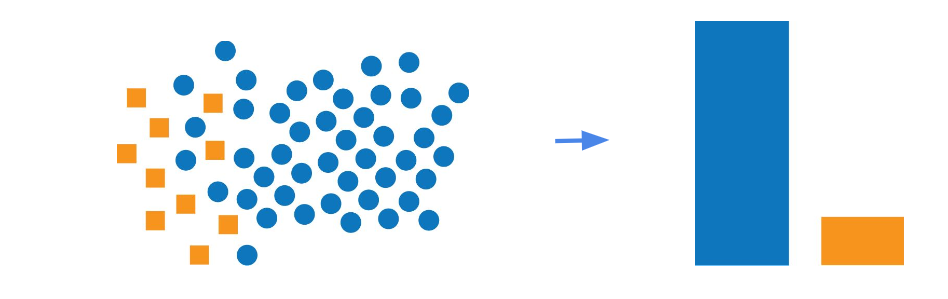

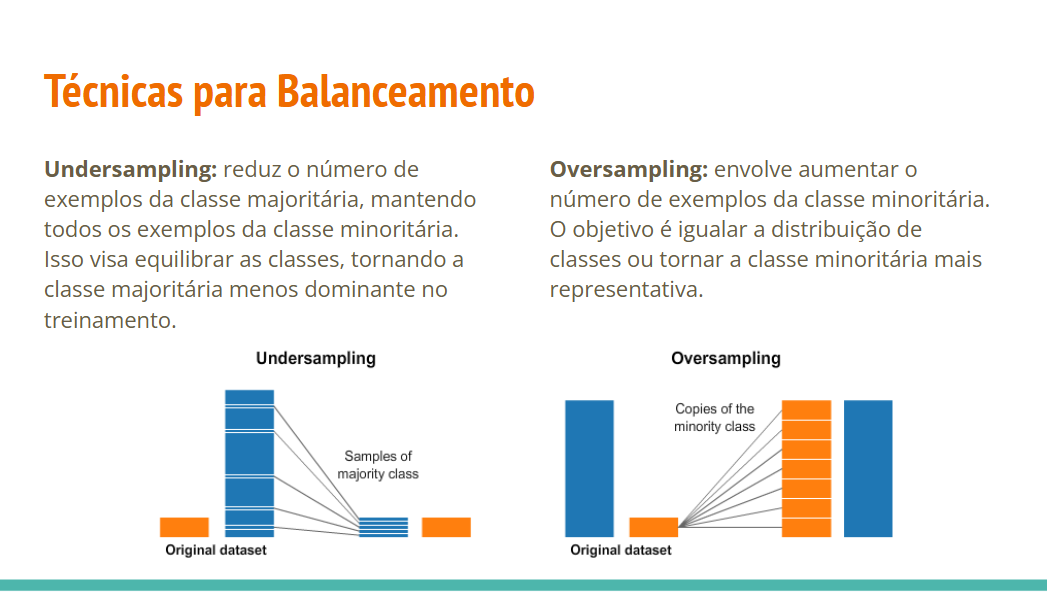

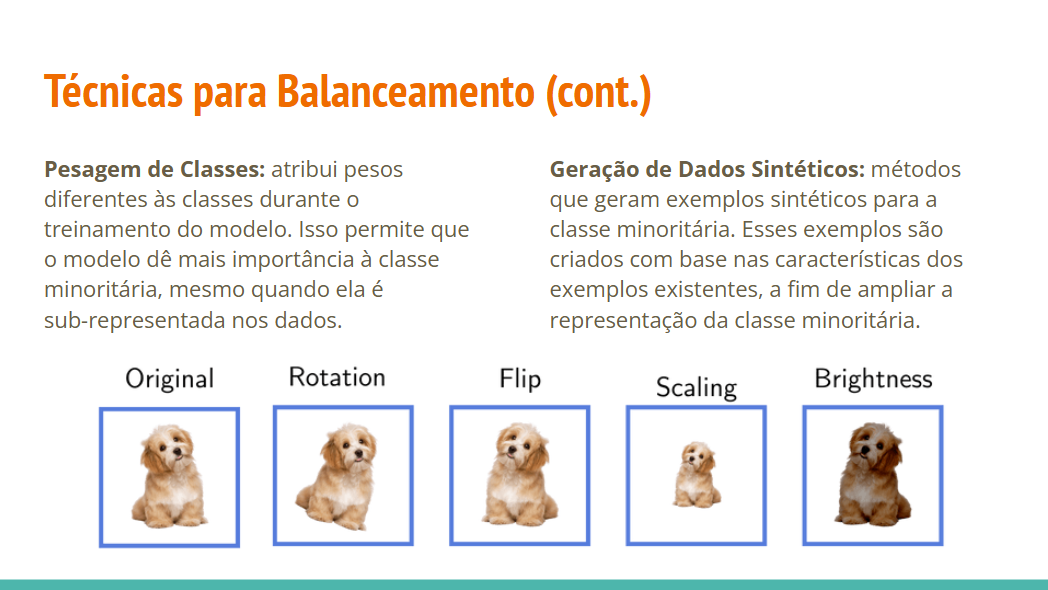

### 6. Escalonamento

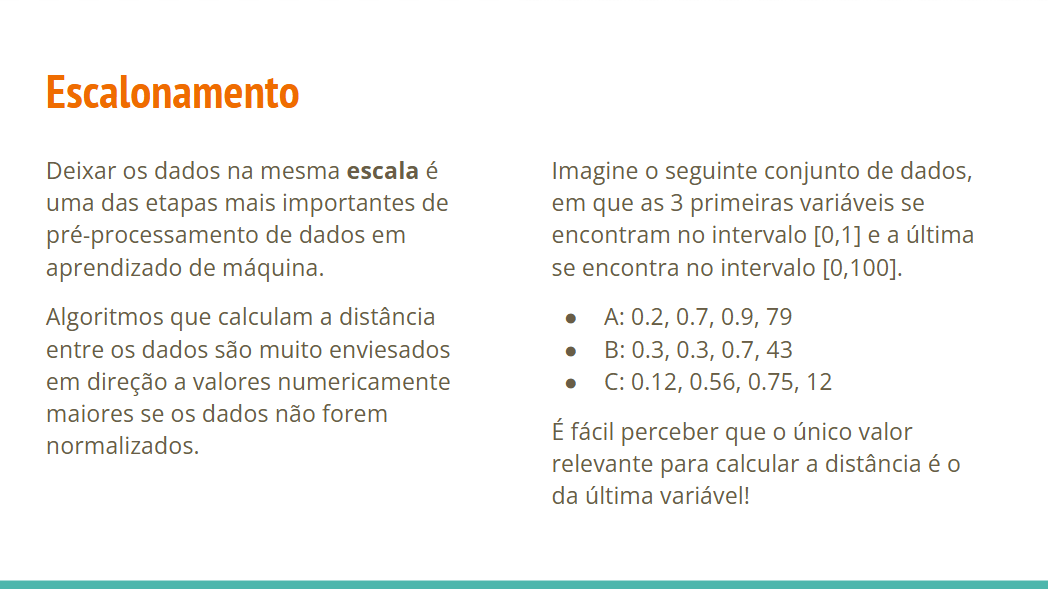

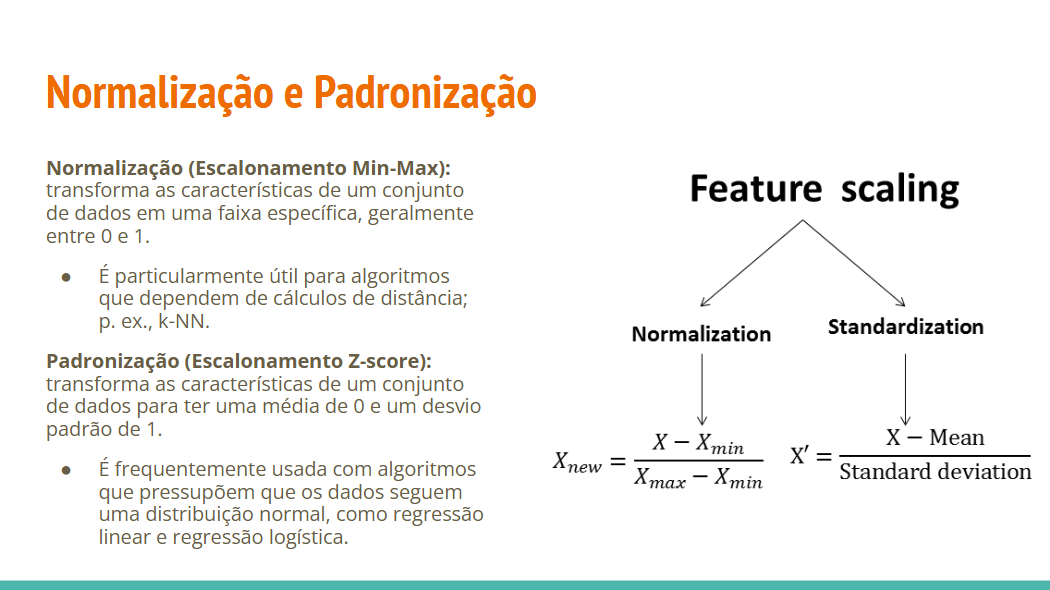

Vamos fazer um escalonamento **z-score** na coluna `Horas de estudo por semana`.

In [23]:
# Selecionando a variável horas
horas = df['Horas de estudo por semana']

scaler = StandardScaler()

# Transforma em matriz 2D (porque a função espera um dataframe 2D)
horas_normalizada = scaler.fit_transform(horas.values.reshape(-1, 1))

horas_normalizada[:5]

array([[ 0.74194581],
       [-0.43946413],
       [-0.31024742],
       [ 0.4281338 ],
       [ 0.05894319]])

**Importante:** o cálculo das estatísticas de normalização (como média e desvio padrão) deve ser feito apenas com os dados de treino, e depois aplicado tanto no treino quanto no teste. Isso evita vazamento de informação do conjunto de teste.

### 7. Partição do dataset

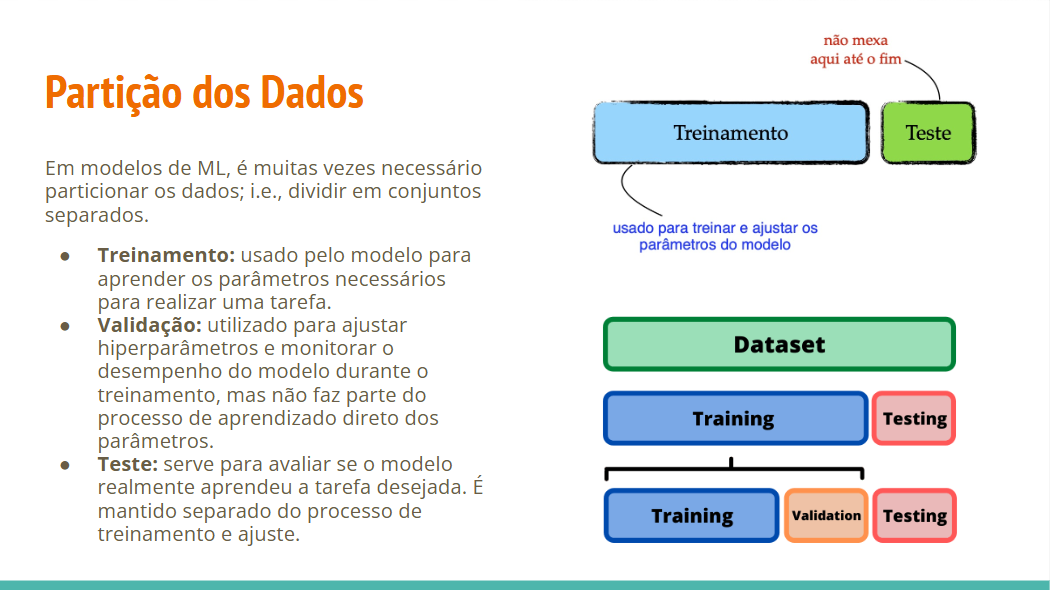

Vamos separar em conjunto de treinamento (que o modelo usa para aprender parâmetros) e conjunto teste (que usamos para medir o poder de generalização do modelo.

In [35]:
# Dividindo o dataset em 80% treino e 20% teste
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

print(f"Tamanho do conjunto de treino: {len(train_df)}")
print(f"Tamanho do conjunto de teste: {len(test_df)}")

Tamanho do conjunto de treino: 116
Tamanho do conjunto de teste: 29


O parâmetro `stratify` no `train_test_split` garante que a proporção das classes (por exemplo, positivos e negativos) seja preservada tanto no conjunto de treino quanto no de teste. Isso é importante especialmente em problemas de classificação desequilibrada, para evitar que uma das classes fique sub-representada em algum dos conjuntos.

## Exercício

Você trabalhará com um conjunto de dados real composto por informações fisicoquímicas de vinhos portugueses. Cada linha representa uma amostra de vinho (tinto ou branco) e suas características laboratoriais, como acidez, pH, teor alcoólico, entre outras.

### Dataset

O dataset será disponibilizado via **Canvas** e contém dados de vinhos tintos e brancos em um único arquivo `.csv`. Você pode consultar a documentação original no link abaixo:

**Link:** https://www.kaggle.com/datasets/uciml/red-wine-quality-cortez-et-al-2009

**Observação:** A variável type foi adicionada para indicar se o vinho é tinto ou branco.

### Etapas Sugeridas

O roteiro abaixo apresenta traz os principais pontos que seu relatório deveria abordar. Você tem liberdade para construir o seu projeto na ordem que achar mais apropriada.

**1. Entendimento dos dados**

* Quantas variáveis há? Quais são numéricas, categóricas, ordinais?

* Qual o significado dessas variáveis?

* Como está a distribuição da variável `quality`?

**2. Análise exploratória**

* Como se distribuem os vinhos tintos e brancos no dataset?

* Como cada variável se correlaciona com a variável `quality`?

* Que diferenças existem entre vinhos tintos e brancos em termos das variáveis químicas?

**3. Tratamento de dados**

* Como lidou com a variável `type` (codificação)?

* As variáveis precisam de normalização/padronização?

* Há colinearidade entre variáveis? Você retiraria alguma das variáveis para realizar uma regressão linear?


##1. Entendimento dos dados

In [26]:
df_vinho = pd.read_csv('winequality.csv')
df_vinho.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


In [28]:
df_vinho.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality', 'type'],
      dtype='object')

In [29]:
# Quantas variáveis há?
print(f"Número de variáveis: {len(df_vinho.columns)}")

Número de variáveis: 13


In [30]:
df_vinho['quality'].value_counts()

,count
quality,
6,2836
5,2138
7,1079
4,216
8,193
3,30
9,5


##2. Análise exploratória

In [31]:
df_vinho['type'].value_counts()

,count
type,
white,4898
red,1599


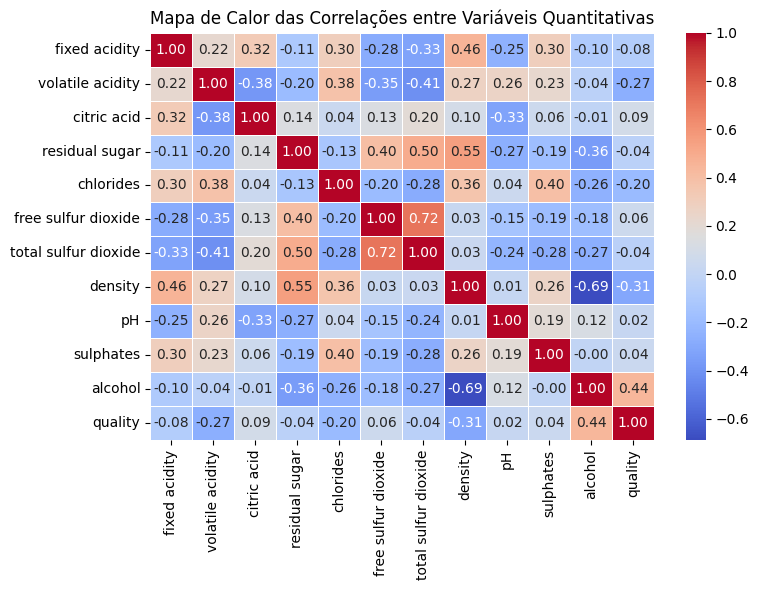

In [34]:
# Seleciona apenas variáveis numéricas
df_vinho_numericas = df_vinho.select_dtypes(include=['float64', 'int64'])

# Calcula a matriz de correlação
matriz_corr = df_vinho_numericas.corr()

# Gera o heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Mapa de Calor das Correlações entre Variáveis Quantitativas')
plt.tight_layout()
plt.show()

##3. Tratamento de dados